# Fuentes de datos y colaboración

Este notebook tiene dos objetivos: identificar y clasificar las fuentes de
datos del proyecto (qué son, en qué formato llegan, qué licencia tienen, qué
riesgo de privacidad cargan), y documentar el acuerdo de trabajo
colaborativo del equipo.

En el ciclo CRISP-DM, este notebook corresponde a **Data Understanding**:
todavía no se modela nada, se caracterizan las fuentes antes de decidir qué
hacer con ellas. `01_exploracion_csv.ipynb` y `02_exploracion_waymo.ipynb`
ya cubrieron el EDA de cada fuente en detalle; acá el foco es la fuente en
sí misma (formato, licencia, procedencia), no el contenido estadístico de
los datos.

No depende del catálogo de Kedro: todas las rutas son relativas desde
`notebooks/` hacia `data/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

AZUL = "#2a78d6"
AMARILLO = "#eda100"
VERDE = "#1baf7a"
ROJO = "#e34948"
GRIS = "#c3c2b7"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"

SEGMENTOS = {
    "10023947602400723454_1120_000_1140_000": {"weather": "sunny", "time_of_day": "Day",       "location": "location_sf"},
    "10206293520369375008_2796_800_2816_800": {"weather": "sunny", "time_of_day": "Night",     "location": "location_phx"},
    "11017034898130016754_697_830_717_830":   {"weather": "sunny", "time_of_day": "Dawn/Dusk", "location": "location_other"},
    "6791933003490312185_2607_000_2627_000":  {"weather": "rain",  "time_of_day": "Dawn/Dusk", "location": "location_phx"},
}

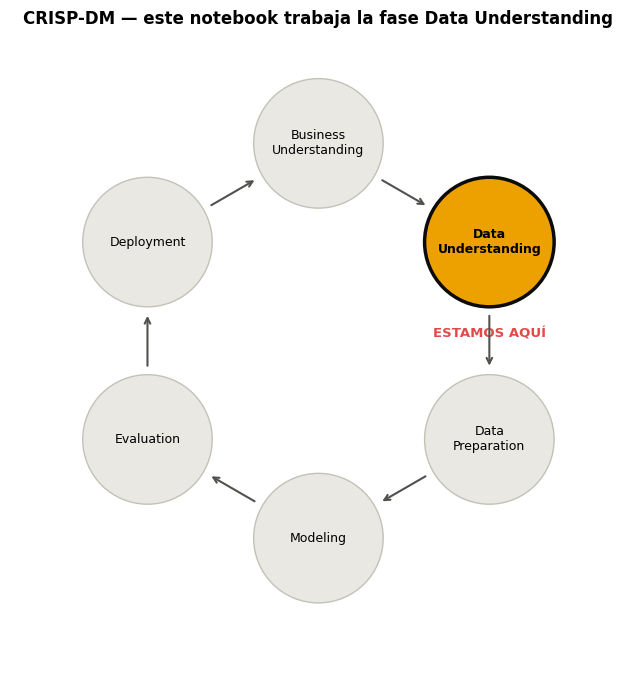

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

etapas = ["Business\nUnderstanding", "Data\nUnderstanding", "Data\nPreparation",
          "Modeling", "Evaluation", "Deployment"]
n = len(etapas)
angulos = np.linspace(90, 90 - 360, n, endpoint=False)
radio = 3.2
xs = radio * np.cos(np.radians(angulos))
ys = radio * np.sin(np.radians(angulos))

for etapa, x, y in zip(etapas, xs, ys):
    es_actual = "Data\nUnderstanding" == etapa
    color = AMARILLO if es_actual else "#e9e8e3"
    borde = INK_PRIMARY if es_actual else GRIS
    circ = plt.Circle((x, y), 1.05, facecolor=color, edgecolor=borde,
                       linewidth=2.5 if es_actual else 1, zorder=3)
    ax.add_patch(circ)
    ax.text(x, y, etapa, ha="center", va="center", fontsize=9,
             fontweight="bold" if es_actual else "normal", zorder=4)
    if es_actual:
        ax.text(x, y - 1.55, "ESTAMOS AQUÍ", ha="center", fontsize=9.5,
                 color=ROJO, fontweight="bold")

for i in range(n):
    x0, y0 = xs[i], ys[i]
    x1, y1 = xs[(i + 1) % n], ys[(i + 1) % n]
    dx, dy = x1 - x0, y1 - y0
    dist = np.hypot(dx, dy)
    ux, uy = dx / dist, dy / dist
    inicio = (x0 + ux * 1.15, y0 + uy * 1.15)
    fin = (x1 - ux * 1.15, y1 - uy * 1.15)
    ax.annotate("", xy=fin, xytext=inicio,
                 arrowprops=dict(arrowstyle="->", color=INK_SECONDARY, lw=1.5))

ax.set_xlim(-5, 5)
ax.set_ylim(-5.5, 5)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("CRISP-DM — este notebook trabaja la fase Data Understanding", fontweight="bold")
fig.tight_layout()
plt.show()

## Bloque 1 — Tipos de aprendizaje y clasificación del problema

| Tipo | Qué necesita | Ejemplo en este proyecto |
|---|---|---|
| Supervisado | Un target conocido (etiqueta) para cada observación | Predecir `tiene_camara`: el target se construye cruzando `lidar_box` con `camera_to_lidar_box_association`, así que existe para cada detección |
| No supervisado | Datos sin etiqueta, se busca estructura o agrupamiento | Agrupar detecciones LiDAR por similitud de tamaño y velocidad, sin usar `tiene_camara` para nada |
| Por refuerzo | Un agente que actúa, recibe una recompensa o castigo, y ajusta su política con el tiempo | Un sistema que decide en tiempo real cuándo pedir una segunda validación por cámara, y aprende de si esa decisión resultó útil |

Predecir `tiene_camara` es un problema **supervisado**: el target no es una
suposición ni una etiqueta que haya que armar a mano, es el resultado
directo y verificable de un cruce entre dos fuentes de datos que ya
existen (`lidar_box` y `camera_to_lidar_box_association`, ver Bloque 2 de
`02_exploracion_waymo.ipynb`).

In [3]:
problemas = {
    "Predecir si una detección LiDAR tiene correspondencia en cámara": "supervisado",
    "Agrupar detecciones LiDAR por comportamiento similar": "no supervisado",
    "Decidir cuándo el sistema de percepción debe pedir validación adicional": "refuerzo",
    "Estimar qué tipo de objeto es una detección dado su tamaño y puntos LiDAR": "supervisado",
}


def clasificar_tipo_aprendizaje(pregunta: str) -> str:
    """Clasifica una pregunta de negocio segun palabras clave simples."""
    texto = pregunta.lower()
    if "agrupar" in texto:
        return "no supervisado"
    if "decidir cuándo" in texto or "decidir cuando" in texto:
        return "refuerzo"
    return "supervisado"


for pregunta, esperado in problemas.items():
    obtenido = clasificar_tipo_aprendizaje(pregunta)
    assert obtenido == esperado, f"{pregunta!r}: esperado {esperado!r}, obtenido {obtenido!r}"
    print(f"[{obtenido:15s}] {pregunta}")

print("\nOK: las 4 clasificaciones coinciden con lo esperado.")

[supervisado    ] Predecir si una detección LiDAR tiene correspondencia en cámara
[no supervisado ] Agrupar detecciones LiDAR por comportamiento similar
[refuerzo       ] Decidir cuándo el sistema de percepción debe pedir validación adicional
[supervisado    ] Estimar qué tipo de objeto es una detección dado su tamaño y puntos LiDAR

OK: las 4 clasificaciones coinciden con lo esperado.


## Bloque 2 — Fuentes de datos: leer desde distintos formatos

En un proyecto real los datos rara vez llegan como un único CSV ordenado.
En este proyecto conviven 3 formatos distintos, con 3 formas distintas de
cargarlos: un CSV plano, un Parquet ya procesado, y un metadato que en
Waymo real viene de una llamada a una API/BigQuery (acá lo simulamos con
`json.dumps`/`json.loads` sobre el mismo diccionario `SEGMENTOS`).

In [4]:
# Fuente 1 - CSV crudo
df_csv = pd.read_csv("../data/01_raw/detecciones_waymo_like.csv")
print(f"CSV: {df_csv.shape}, tipos object: {(df_csv.dtypes == 'object').sum()}")

CSV: (40680, 16), tipos object: 8


In [5]:
# Fuente 2 - Parquet procesado
df_parquet = pd.read_parquet("../data/02_intermediate/detecciones_limpias.parquet")
print(f"Parquet: {df_parquet.shape}, tipos object: {(df_parquet.dtypes == 'object').sum()}")

Parquet: (39800, 18), tipos object: 6


In [6]:
# Fuente 3 - Diccionario Python (metadato de segmentos reales, como si viniera de una API JSON)
import json

metadato_json = json.dumps(SEGMENTOS)  # simula la respuesta de una API
metadato = json.loads(metadato_json)
df_meta = pd.DataFrame(metadato).T.reset_index().rename(columns={"index": "segment_id"})
print(f"JSON/API: {df_meta.shape}")
print(df_meta)

assert df_meta.shape == (4, 4), "el metadato deberia tener 4 segmentos y 4 columnas"
assert list(df_meta.columns) == ["segment_id", "weather", "time_of_day", "location"]
print("\nOK: el metadato tiene 4 segmentos con las 4 columnas esperadas.")

JSON/API: (4, 4)
                               segment_id weather time_of_day        location
0  10023947602400723454_1120_000_1140_000   sunny         Day     location_sf
1  10206293520369375008_2796_800_2816_800   sunny       Night    location_phx
2    11017034898130016754_697_830_717_830   sunny   Dawn/Dusk  location_other
3   6791933003490312185_2607_000_2627_000    rain   Dawn/Dusk    location_phx

OK: el metadato tiene 4 segmentos con las 4 columnas esperadas.


`df_csv` y `df_parquet` no son la misma tabla fila por fila (`df_parquet`
es el resultado ya limpio de `df_csv`, con 880 filas menos y 2 columnas
más, ver `01_exploracion_csv.ipynb`), así que no se comparan por igualdad:
lo que se verifica es que ambas cargan correctamente como un DataFrame
tabular con tipos consistentes, cada una desde su propio formato.

**Estructurada:** esquema fijo y tabular, conocido de antemano (columnas y
tipos no cambian de una fila a otra). El CSV sintético y los parquet de
`lidar_box` son estructurados: cada fila es una detección con exactamente
las mismas columnas.

**Semiestructurada:** tiene una organización (llaves, jerarquía) pero no un
esquema tabular fijo: puede variar de un registro a otro. El metadato de
segmentos como JSON es semiestructurado: es un diccionario anidado
(`segment_id → {weather, time_of_day, location}`), no una tabla hasta que
alguien decide aplanarlo (como se hizo arriba con `.T.reset_index()`). El
componente `stats` real de Waymo, que describe cada segmento, tiene esta
misma naturaleza.

**No estructurada:** sin esquema ni organización tabular en absoluto. Las
imágenes de `camera_image` de Waymo (no descargadas en este proyecto) son
no estructuradas: un modelo tiene que extraer la información (bordes,
objetos, texto) sin que exista una columna que ya la contenga.

## Bloque 3 — Clasificación de las fuentes del proyecto

In [7]:
fuentes = pd.DataFrame([
    {
        "fuente": "CSV sintético",
        "tipo": "estructurada",
        "formato": "CSV",
        "ruta": "data/01_raw/detecciones_waymo_like.csv",
        "filas": 40680,
        "columnas": 16,
        "licencia": "uso académico",
        "datos_personales": "No",
    },
    {
        "fuente": "Waymo lidar_box",
        "tipo": "estructurada",
        "formato": "Parquet",
        "ruta": "gs://waymo_open_dataset_v_2_0_1/training/lidar_box/",
        "filas": 34098,
        "columnas": 21,
        "licencia": "no comercial",
        "datos_personales": "Indirecto (trayectorias)",
    },
    {
        "fuente": "Waymo camera_to_lidar_box_association",
        "tipo": "estructurada",
        "formato": "Parquet",
        "ruta": "gs://waymo_open_dataset_v_2_0_1/training/camera_to_lidar_box_association/",
        "filas": 6737,
        "columnas": 5,
        "licencia": "no comercial",
        "datos_personales": "No",
    },
    {
        "fuente": "Metadato de segmentos (stats Waymo)",
        "tipo": "semiestructurada",
        "formato": "Parquet/censo",
        "ruta": "gs://waymo_open_dataset_v_2_0_1/training/stats/",
        "filas": 798,
        "columnas": 10,
        "licencia": "no comercial",
        "datos_personales": "No",
    },
])
print(fuentes.to_string(index=False))

                               fuente             tipo       formato                                                                      ruta  filas  columnas      licencia         datos_personales
                        CSV sintético     estructurada           CSV                                    data/01_raw/detecciones_waymo_like.csv  40680        16 uso académico                       No
                      Waymo lidar_box     estructurada       Parquet                       gs://waymo_open_dataset_v_2_0_1/training/lidar_box/  34098        21  no comercial Indirecto (trayectorias)
Waymo camera_to_lidar_box_association     estructurada       Parquet gs://waymo_open_dataset_v_2_0_1/training/camera_to_lidar_box_association/   6737         5  no comercial                       No
  Metadato de segmentos (stats Waymo) semiestructurada Parquet/censo                           gs://waymo_open_dataset_v_2_0_1/training/stats/    798        10  no comercial                       No


Nota sobre `Waymo camera_to_lidar_box_association`: el archivo crudo tiene
6.737 filas (concatenando los 4 parquet descargados). Ese número **no** es
el mismo que las 5.352 detecciones que terminan marcadas con
`tiene_camara=1` tras cruzar esta fuente con `lidar_box`: son dos cifras
distintas (filas de la fuente vs. resultado del cruce), y conviene no
confundirlas, ver Bloque 5 y la ficha de cierre.

## Bloque 4 — Lista de chequeo de privacidad por fuente

1. ¿Contiene datos personales?
2. ¿Se puede reidentificar combinando columnas?
3. ¿La licencia permite el uso que le damos?
4. ¿Necesitamos todas las columnas?
5. ¿Podemos declarar origen y fecha?

**CSV sintético**
1. No: es generado, no hay personas reales detrás de ninguna fila.
2. No aplica: no hay individuos reales que reidentificar.
3. Sí: uso académico, que es exactamente el uso que le damos.
4. No: `sensor_version` se elimina por no tener varianza (pipeline
   `preprocesamiento`), el resto sí se usa.
5. Parcialmente: sabemos que lo generó el docente del curso y cuándo lo
   recibimos, pero no hay un origen "real" que declarar porque no proviene
   de una captura física, es sintético por diseño.

**Waymo lidar_box**
1. No de forma directa (no hay nombre, rostro ni patente en estas
   columnas), pero sí de forma indirecta: la trayectoria de un peatón a lo
   largo de un segmento es un patrón de movimiento de una persona real en
   un espacio público (ver `05_etica_sesgos_privacidad.ipynb`, Bloque 4).
2. Sí, dentro del dataset: `segment_id` + `timestamp_micros` + `id_interno`
   (o `key.laser_object_id` en los datos reales) da 100% de combinaciones
   únicas, suficiente para reconstruir la trayectoria completa de un mismo
   objeto.
3. Sí, mientras el uso sea no comercial y no se redistribuyan los datos:
   por eso `data/01_raw/waymo/` está en `.gitignore` (verificado en la
   celda siguiente), una decisión técnica que existe para cumplir esa
   condición de la licencia, no una preferencia de organización de
   carpetas.
4. No necesariamente todas: para predecir `tiene_camara` no hacen falta
   `key.laser_object_id` ni `key.frame_timestamp_micros` como atributos del
   modelo (ver minimización en `05_etica_sesgos_privacidad.ipynb`, Bloque
   4).
5. Sí: origen (Waymo LLC, flota propia), fecha (2019) y ubicación (SF,
   Phoenix, "location_other") están documentados en `README.md`, sección 4.

**Waymo camera_to_lidar_box_association**
1. No: son solo identificadores (`segment_id`, `timestamp_micros`,
   `camera_name`, `camera_object_id`, `laser_object_id`), sin coordenadas
   ni atributos físicos del objeto.
2. Indirectamente sí, en combinación con `lidar_box`: esta fuente es
   justamente la que conecta un `laser_object_id` con una detección de
   cámara en un instante preciso, el mismo mecanismo de reidentificación
   que en `lidar_box`.
3. Sí, misma licencia no comercial que `lidar_box`, mismo tratamiento vía
   `.gitignore`.
4. Sí, se necesitan las 5: son las que permiten construir `tiene_camara`
   (ver `construir_target_binario` en
   `src/waymo_evaluacion/pipelines/ingesta_waymo/nodes.py`).
5. Sí, mismo origen y fecha que `lidar_box`: son el mismo segmento y el
   mismo operativo de captura.

In [8]:
from pathlib import Path

ruta_waymo = Path("../data/01_raw/waymo")
assert ruta_waymo.exists(), "la carpeta existe localmente"

gitignore = Path("../.gitignore").read_text(encoding="utf-8")
assert "data/01_raw/waymo" in gitignore, "waymo debe estar en .gitignore"

print("data/01_raw/waymo existe localmente pero esta en .gitignore -> cumple la licencia")

data/01_raw/waymo existe localmente pero esta en .gitignore -> cumple la licencia


## Bloque 5 — Sesgo de muestreo en las fuentes

Importante distinguir dos escalas distintas: el **censo completo** de los
798 segmentos de entrenamiento de Waymo (documentado, no un archivo
descargado en este proyecto) y la **muestra de 4 segmentos**
(`waymo_con_target.parquet`) que sí tenemos localmente. Son números
distintos a propósito: la muestra se eligió para maximizar contraste
climático, no para replicar la proporción real del conjunto completo.

In [9]:
waymo = pd.read_parquet("../data/02_intermediate/waymo_con_target.parquet")

# Censo completo de los 798 segmentos de entrenamiento (documentado en
# 05_etica_sesgos_privacidad.ipynb, Bloque 1; no se recalcula aca porque no
# tenemos los 798 segmentos descargados, solo 4).
n_sunny_censo, n_rain_censo, n_total_censo = 793, 5, 798
pct_sunny_censo = n_sunny_censo / n_total_censo * 100
pct_rain_censo = n_rain_censo / n_total_censo * 100

print("Censo completo (798 segmentos de entrenamiento, documentado):")
print(f"  sunny: {pct_sunny_censo:.1f}% ({n_sunny_censo} de {n_total_censo})")
print(f"  rain:  {pct_rain_censo:.1f}% ({n_rain_censo} de {n_total_censo})")

assert abs(pct_sunny_censo - 99.4) < 0.05, "el censo documentado deberia dar 99.4% sunny"
assert abs(pct_rain_censo - 0.6) < 0.05, "el censo documentado deberia dar 0.6% rain"
print("OK: el censo documentado (99.4% / 0.6%) es consistente con 793/5 de 798.")

Censo completo (798 segmentos de entrenamiento, documentado):
  sunny: 99.4% (793 de 798)
  rain:  0.6% (5 de 798)
OK: el censo documentado (99.4% / 0.6%) es consistente con 793/5 de 798.


In [10]:
# Distribucion real dentro de NUESTRA muestra de 4 segmentos (no del censo).
weather_muestra = waymo["weather"].value_counts(normalize=True) * 100
weather_muestra_segmento = waymo.groupby("segment_id")["weather"].first().value_counts()

print("Distribucion de weather en la MUESTRA (waymo_con_target), por deteccion:")
print(weather_muestra.round(2))
print(f"\nPor segmento: {weather_muestra_segmento.to_dict()} (3 sunny, 1 rain, de 4 en total)")

location_muestra = waymo["location"].value_counts(normalize=True) * 100
print("\nDistribucion de location en la muestra, por deteccion:")
print(location_muestra.round(2))

Distribucion de weather en la MUESTRA (waymo_con_target), por deteccion:
weather
sunny    79.95
rain     20.05
Name: proportion, dtype: float64

Por segmento: {'sunny': 3, 'rain': 1} (3 sunny, 1 rain, de 4 en total)

Distribucion de location en la muestra, por deteccion:
location
location_sf       54.65
location_phx      28.47
location_other    16.88
Name: proportion, dtype: float64


**Riesgo de sesgo, con cifra:** el 99,4% de los 798 segmentos de
entrenamiento son en condiciones soleadas (793 de 798). Un modelo entrenado
con esta fuente no ha visto llover en 793 de 798 segmentos: prácticamente
toda su experiencia de entrenamiento es en un régimen de iluminación y
visibilidad de cámara favorable, que es justo la condición en la que el
LiDAR y la cámara tienden a coincidir más (ver `05_etica_sesgos_privacidad.ipynb`,
Bloque 3: la tasa de `tiene_camara=1` en `sunny` es 15,4 veces la de
`rain`). La muestra de 4 segmentos de este proyecto, con 1 de 4 en lluvia,
compensa parcialmente ese desbalance para efectos de este trabajo, pero no
cambia el sesgo real del conjunto de entrenamiento completo que Waymo
publicó.

## Bloque 6 — Acuerdo de trabajo colaborativo

| Integrante | Rama GitHub | Responsabilidad principal |
|---|---|---|
| maicolhernandez | `maicolhernandez` | Pipeline Kedro, EDA Waymo, integración de datos reales |
| francismoya | `francismoya` | EDA CSV sintético, análisis de calidad, documentación |

**Acuerdos del equipo:**

1. Nunca pushear directamente a `main`: todo cambio entra por Pull Request,
   revisado antes de integrarse.
2. Los datos de Waymo van en `.gitignore`: es cumplimiento de licencia, no
   una preferencia de organización (ver Bloque 4).
3. Los umbrales y decisiones de limpieza van en `conf/base/parameters.yml`,
   nunca hardcodeados en el código de los nodos (ver
   `src/waymo_evaluacion/pipelines/preprocesamiento/nodes.py`).
4. Cada decisión de limpieza queda documentada en la tabla de decisiones de
   la sección 7 de `01_exploracion_csv.ipynb`, con la cifra y la
   justificación, antes de implementarse como función en el pipeline.

## Cierre — Ficha de fuentes del proyecto

**Equipo:** maicolhernandez / francismoya
**Caso de negocio:** conducción autónoma — percepción sensorial
**Pregunta:** ¿puede una detección LiDAR predecirse como confirmada o no
por cámara?
**Tipo de aprendizaje:** supervisado — el target `tiene_camara` es
construible a partir de los datos de asociación, no hay que suponerlo ni
etiquetarlo a mano (Bloque 1).

**Fuente 1 — CSV sintético:** estructurada, CSV, 40.680 filas × 16
columnas, uso académico, sin datos personales, entregada por el docente del
curso MLY1101.

**Fuente 2 — Waymo `lidar_box`:** estructurada, Parquet, 34.098 filas en 4
segmentos, licencia no comercial, datos indirectamente identificables
(trayectorias de peatones), descargada en septiembre 2026 desde
`gs://waymo_open_dataset_v_2_0_1/`.

**Fuente 3 — Waymo `camera_to_lidar_box_association`:** estructurada,
Parquet, 6.737 filas de asociación cámara-LiDAR en el archivo crudo (6.099
tras deduplicar por segmento + instante + objeto), misma licencia que la
Fuente 2, sin datos personales directos. De esas asociaciones, 5.352
detecciones de `lidar_box` terminan marcadas como `tiene_camara=1` tras el
cruce (Bloque 3 de `02_exploracion_waymo.ipynb`): esa cifra describe el
resultado del cruce, no el tamaño de esta fuente.

**Riesgo de sesgo:** 793 de 798 segmentos (99,4%) del conjunto de
entrenamiento son en condiciones soleadas. Un modelo entrenado con estas
fuentes tendrá, con alta probabilidad, peor desempeño en lluvia, que es
exactamente la condición más exigente para la percepción autónoma (menor
visibilidad de cámara, mayor necesidad de confiar en el LiDAR).